# 复现回测结果

验证本地回测与 `--from-predictions` 结果一致。

In [1]:
1

1

In [1]:
import os, sys, pickle, json
import pandas as pd
import numpy as np
sys.path.insert(0, '../code/src')
from backtest import ETFBacktester, run_backtest, run_backtest_from_predictions
import warnings
warnings.filterwarnings('ignore')

## 配置

In [2]:
MODEL_FILE = "best_model_sliding.pth"
DATA_PATH = "../etf_data/etf_74.csv"
CACHE_DIR = "../output/predictions_cache"
BT_CACHE_DIR = "../output/backtest_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(BT_CACHE_DIR, exist_ok=True)

START_DATE = "2026-04-01"
END_DATE = "2026-05-12"
TOP_K = 3
REBALANCE_DAYS = 5
POSITION_PCT = 0.95
INITIAL_CAPITAL = 100000

In [3]:
import glob
from tqdm import tqdm

BASE_DIR = "../model"
# DL models (per-trial PyTorch checkpoints)
DL_TYPES = [
    "bayes_itransformer_74_3_2026-01-01_2026-03-31",
    "bayes_dlinear_74_3_2026-01-01_2026-03-31",
    "bayes_gru_74_3_2026-01-01_2026-03-31",
    "bayes_patchtst_74_3_2026-01-01_2026-03-31",
    "bayes_mamba_74_3_2026-01-01_2026-03-31",
    "bayes_nlinear_74_3_2026-01-01_2026-03-31",
    "bayes_timesnet_74_3_2026-01-01_2026-03-31",
    "bayes_tcn_74_3_2026-01-01_2026-03-31",
]
# ML models (retrained best model as .pkl)
ML_TYPES = [
    "bayes_xgb_2026-01-01_2026-03-31",
    "bayes_lightgbm_2026-01-01_2026-03-31",
    "bayes_catboost_2026-01-01_2026-03-31",
    "grid_xgb_2026-01-01_2026-03-31",
]
# 合并方便展示循环用
MODEL_TYPES = DL_TYPES + ML_TYPES
# 数据加载需要 DL 模型的 scaler
MODEL_DIR = f"../model/{DL_TYPES[0]}/exp_0"


EXPERIMENTS = []
# DL: scan exp_* subdirs for .pth checkpoints
for mt in DL_TYPES:
    cnt = 0
    for exp_dir in sorted(glob.glob(f"{BASE_DIR}/{mt}/exp_*")):
        if os.path.exists(f"{exp_dir}/best_model_sliding.pth"):
            EXPERIMENTS.append((exp_dir, "best_model_sliding.pth"))
        if os.path.exists(f"{exp_dir}/best_model.pth"):
            EXPERIMENTS.append((exp_dir, "best_model.pth"))
        if os.path.exists(f"{exp_dir}/best_model_ndcg.pth"):
            EXPERIMENTS.append((exp_dir, "best_model_ndcg.pth"))
        cnt += 1
    print(f"{mt}: 共 {cnt} 个实验")
# ML: scan final/ subdir for model.pkl
for mt in ML_TYPES:
    final_dir = f"{BASE_DIR}/{mt}/final"
    if os.path.exists(f"{final_dir}/model.pkl"):
        # Store as (final_dir, model.pkl) for backtester compatibility
        # experiment name = {mt}/final
        EXPERIMENTS.append((final_dir, "model.pkl"))
        print(f"{mt}: 1 ML模型 (retrained)")
print(f"共 {len(EXPERIMENTS)} 个实验 (DL + ML)")

bayes_itransformer_74_3_2026-01-01_2026-03-31: 共 1 个实验
bayes_dlinear_74_3_2026-01-01_2026-03-31: 共 82 个实验
bayes_gru_74_3_2026-01-01_2026-03-31: 共 82 个实验
bayes_patchtst_74_3_2026-01-01_2026-03-31: 共 117 个实验
bayes_mamba_74_3_2026-01-01_2026-03-31: 共 80 个实验
bayes_nlinear_74_3_2026-01-01_2026-03-31: 共 64 个实验
bayes_timesnet_74_3_2026-01-01_2026-03-31: 共 82 个实验
bayes_tcn_74_3_2026-01-01_2026-03-31: 共 81 个实验
bayes_xgb_2026-01-01_2026-03-31: 1 ML模型 (retrained)
bayes_lightgbm_2026-01-01_2026-03-31: 1 ML模型 (retrained)
bayes_catboost_2026-01-01_2026-03-31: 1 ML模型 (retrained)
grid_xgb_2026-01-01_2026-03-31: 1 ML模型 (retrained)
共 1765 个实验 (DL + ML)


## 遍历所有实验，一次性缓存 + 回测

In [4]:
import time

cached_data, cached_features = ETFBacktester.load_data_once(
    data_path=DATA_PATH,
    scaler_path=f'{MODEL_DIR}/scaler.pkl',
    feature_num='39',
    verbose=True,
    store_unscaled=True,  # ML models need unscaled features
)


加载并缓存数据: ../etf_data/etf_74.csv


特征工程: 100%|██████████| 74/74 [00:03<00:00, 22.92it/s]


数据缓存完成: 78357 条记录, 74 只股票


In [5]:
all_results = []
for exp_dir, mf in tqdm(EXPERIMENTS, desc="回测"):
    cache_key = f"{exp_dir}/{mf}"
    safe_name = cache_key.replace("\\", "/").replace('../', '').replace('./', '').replace('/', '_')
    cache_path = os.path.join(CACHE_DIR, f"{safe_name}.pkl")
    
    if not os.path.exists(cache_path):
        try:
            bt = ETFBacktester.from_cached_data(
                model_dir=exp_dir, cached_data=cached_data,
                cached_features=cached_features, device='cpu',
                model_file=mf, verbose=False,
            )
            preds = bt.generate_predictions_dict(start_date=START_DATE, end_date=END_DATE, rebalance_days=REBALANCE_DAYS, first_rebalance_date=START_DATE)
            with open(cache_path, 'wb') as f:
                pickle.dump(preds, f)
            del bt.model, bt
        except Exception as e:
            print(f'FAIL gen {cache_key}: {e}')
            continue
    else:
        with open(cache_path, 'rb') as f:
            preds = pickle.load(f)
    
    for mode in ['close', 'open']:
        bt_cache_key = f"{safe_name}_{mode}.pkl"
        bt_cache_path = os.path.join(BT_CACHE_DIR, bt_cache_key)
        if os.path.exists(bt_cache_path):
            with open(bt_cache_path, 'rb') as f:
                row = pickle.load(f)
            all_results.append(row)
            continue
        try:
            r = run_backtest_from_predictions(
                predictions_dict=preds, data_path=DATA_PATH,
                start_date=START_DATE, end_date=END_DATE,
                top_k=TOP_K, rebalance_days=REBALANCE_DAYS,
                position_pct=POSITION_PCT, initial_capital=INITIAL_CAPITAL,
                trade_mode=mode, verbose=False, log=False,
            )
            row = {
                'experiment': exp_dir.replace("\\", "/").split('/')[-2] + '/' + exp_dir.replace("\\", "/").split('/')[-1],
                'model_file': mf, 'trade_mode': mode,
                'return': r.strategy_return,
                'dd': r.max_drawdown,
                'hs300': r.hs300_return,
                'excess': r.excess_return,
                'win_rate': r.rebalance_stats.get('win_rate', 0),
                'avg_return': r.rebalance_stats.get('avg_return', 0),
                'rebalances': r.rebalance_stats.get('total', 0),
            }
            with open(bt_cache_path, 'wb') as f:
                pickle.dump(row, f)
            all_results.append(row)
        except Exception as e:
            print(f'FAIL backtest {cache_key} {mode}: {e}')

df = pd.DataFrame(all_results)
for mode in ['close', 'open']:
    sub = df[df['trade_mode'] == mode].sort_values('return', ascending=False).head(5)
    print(f'\n=== {mode} Top 5 ===')
    for _, r in sub.iterrows():
        print(f'  {r["experiment"]:35s} {r["model_file"]:25s} return={r["return"]:6.2f}%  dd={r["dd"]:5.2f}%  win={r["win_rate"]:5.1f}%  avg={r["avg_return"]:+5.2f}%')

回测:   0%|          | 0/1765 [00:00<?, ?it/s]

回测: 100%|█████████▉| 1764/1765 [1:16:47<00:04,  4.46s/it]

FAIL gen ../model/bayes_catboost_2026-01-01_2026-03-31/final/model.pkl: catboost/libs/data/model_dataset_compatibility.cpp:72: Feature 152 is present in model but not in pool.


回测: 100%|██████████| 1765/1765 [1:16:49<00:00,  2.61s/it]

FAIL gen ../model/grid_xgb_2026-01-01_2026-03-31/final/model.pkl: [10:02:48] C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:1289: Check failed: learner_model_param_.num_feature >= p_fmat->Info().num_col_ (39 vs. 152) : Number of columns does not match number of features in booster.

=== close Top 5 ===
  bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_1 best_model.pth            return= 28.04%  dd= 3.20%  win= 75.0%  avg=+3.88%
  bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_1 best_model_ndcg.pth       return= 28.04%  dd= 3.20%  win= 75.0%  avg=+3.88%
  bayes_gru_74_3_2026-01-01_2026-03-31/exp_0 best_model_ndcg.pth       return= 25.40%  dd= 3.05%  win= 75.0%  avg=+3.35%
  bayes_gru_74_3_2026-01-01_2026-03-31/exp_0 best_model.pth            return= 25.40%  dd= 3.05%  win= 75.0%  avg=+3.35%
  bayes_tcn_74_3_2026-01-01_2026-03-31/exp_12 best_model_sliding.pth    return= 23.37%  dd= 2.34%  win=100.0%  avg=+3.13%

=== open Top 5 ===
  bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_49 bes

In [6]:
df = pd.DataFrame(all_results)
for mode in ['close', 'open']:
    sub = df[df['trade_mode'] == mode].sort_values('avg_return', ascending=False).head(10)
    print(f'\n=== {mode} Top 10 by Avg Return ===')
    display(sub[['experiment', 'model_file', 'return', 'avg_return','dd', 'hs300', 'excess']])


=== close Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
14,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_1,best_model.pth,28.04,3.88,3.20,9.53,18.51
16,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_1,best_model_ndcg.pth,28.04,3.88,3.20,9.53,18.51
992,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_0,best_model.pth,22.07,3.52,3.94,9.53,12.55
1558,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_8,best_model_ndcg.pth,22.07,3.52,3.94,9.53,12.55
1556,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_8,best_model.pth,22.07,3.52,3.94,9.53,12.55
1554,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_8,best_model_sliding.pth,22.07,3.52,3.94,9.53,12.55
990,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_0,best_model_sliding.pth,22.07,3.52,3.94,9.53,12.55
994,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_0,best_model_ndcg.pth,22.07,3.52,3.94,9.53,12.55
3508,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_8,best_model_ndcg.pth,22.72,3.49,2.33,9.53,13.19
3506,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_8,best_model.pth,22.72,3.49,2.33,9.53,13.19



=== open Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
149,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_3,best_model_ndcg.pth,17.30,4.20,2.76,9.53,7.77
147,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_3,best_model.pth,17.30,4.20,2.76,9.53,7.77
1011,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_100,best_model.pth,19.95,4.15,1.62,9.53,10.42
1013,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_100,best_model_ndcg.pth,19.95,4.15,1.62,9.53,10.42
1217,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_27,best_model_ndcg.pth,19.95,4.15,1.62,9.53,10.42
1215,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_27,best_model.pth,19.95,4.15,1.62,9.53,10.42
1009,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_100,best_model_sliding.pth,19.95,4.15,1.62,9.53,10.42
1609,bayes_patchtst_74_3_2026-01-01_2026-03-31/exp_88,best_model_sliding.pth,19.95,4.15,1.62,9.53,10.42
3305,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_49,best_model_ndcg.pth,18.10,3.41,1.92,9.53,8.57
3303,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_49,best_model.pth,18.10,3.41,1.92,9.53,8.57


In [7]:
df = pd.DataFrame(all_results)
df["MODEL_TYPES"] = df['experiment'].apply(lambda x: x.split('/')[0])
for mode in ['open','close']:
    for model_type in MODEL_TYPES:
        if not df[df["MODEL_TYPES"] == model_type].empty:
            # 修正：使用 & 和括号
            mask = (df['trade_mode'] == mode) & (df["MODEL_TYPES"] == model_type)
            sub = df[mask].sort_values('avg_return', ascending=False).head(10)
            
            print(f'\n=== {mode} {model_type} Top 10 by Avg Return ===')
            display(sub[['experiment', 'model_file', 'return', 'avg_return', 'dd', 'hs300', 'excess']])
    print("======="*20)


=== open bayes_itransformer_74_3_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
1,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_sliding.pth,1.94,-1.43,7.31,9.53,-7.59
3,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model.pth,1.94,-1.43,7.31,9.53,-7.59
5,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_ndcg.pth,1.94,-1.43,7.31,9.53,-7.59



=== open bayes_dlinear_74_3_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
147,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_3,best_model.pth,17.30,4.20,2.76,9.53,7.77
149,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_3,best_model_ndcg.pth,17.30,4.20,2.76,9.53,7.77
159,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_31,best_model.pth,14.41,3.27,2.08,9.53,4.88
161,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_31,best_model_ndcg.pth,14.41,3.27,2.08,9.53,4.88
265,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_48,best_model_sliding.pth,12.21,2.83,1.82,9.53,2.68
15,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_1,best_model.pth,12.81,2.76,2.10,9.53,3.28
17,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_1,best_model_ndcg.pth,12.81,2.76,2.10,9.53,3.28
19,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_10,best_model_sliding.pth,15.70,2.61,5.03,9.53,6.17
229,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_42,best_model_sliding.pth,7.24,2.61,5.03,9.53,-2.28
247,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_45,best_model_sliding.pth,15.58,2.57,1.73,9.53,6.05



=== open bayes_gru_74_3_2026-01-01_2026-03-31 Top 10 by Avg Return ===


...

,experiment,model_file,return,avg_return,dd,hs300,excess
3508,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_8,best_model_ndcg.pth,22.72,3.49,2.33,9.53,13.19
3506,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_8,best_model.pth,22.72,3.49,2.33,9.53,13.19
3304,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_49,best_model_ndcg.pth,22.85,3.46,2.30,9.53,13.32
3302,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_49,best_model.pth,22.85,3.46,2.30,9.53,13.32
3390,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_62,best_model_sliding.pth,21.14,3.16,1.91,9.53,11.61
3472,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_74,best_model_ndcg.pth,14.83,3.14,1.44,9.53,5.30
3470,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_74,best_model.pth,14.83,3.14,1.44,9.53,5.30
3060,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_12,best_model_sliding.pth,23.37,3.13,2.34,9.53,13.85
3392,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_62,best_model.pth,15.79,2.98,2.03,9.53,6.26
3394,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_62,best_model_ndcg.pth,15.79,2.98,2.03,9.53,6.26



=== close bayes_xgb_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
3522,bayes_xgb_2026-01-01_2026-03-31/final,model.pkl,8.49,0.5,3.86,9.53,-1.04



=== close bayes_lightgbm_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
3524,bayes_lightgbm_2026-01-01_2026-03-31/final,model.pkl,15.96,2.36,2.1,9.53,6.43


## 策略对比（不同权重分配策略对 Top 模型的影响）


In [8]:
# 用 Top 模型测试不同权重策略
WEIGHT_STRATEGIES = [
    ("equal", {}),
    ("softmax", {"temperature": 1.0}),
    ("softmax", {"temperature": 0.5}),
    ("rank_linear", {}),
    ("risk_parity", {"vol_window": 20}),
    ("score_risk", {"vol_window": 20}),
]

# 取 open Top  实验
TOP_EXPERIMENTS = set()
for mode in ["open"]:
    sub = df[(df["trade_mode"] == mode) & (df["avg_return"] > 0)].sort_values("return", ascending=False)
    for _, r in sub.iterrows():
        TOP_EXPERIMENTS.add((r["experiment"], r["model_file"]))
print(f"将测试 {len(TOP_EXPERIMENTS)} 个实验")
print()

strat_results = []
for (exp_dir_full, mf) in tqdm(TOP_EXPERIMENTS, desc="回测"):
    # Match exactly how main loop computes safe_name
    cache_key = f"../model/{exp_dir_full}/{mf}"
    safe_name = cache_key.replace("../", "").replace("./", "").replace("/", "_")
    cache_path = os.path.join(CACHE_DIR, f"{safe_name}.pkl")
    if not os.path.exists(cache_path):
        print(f"跳过 {exp_dir_full}/{mf}: 无预测缓存")
        continue
    with open(cache_path, "rb") as f:
        preds = pickle.load(f)
    for mode in ["open"]:
        for ws_name, ws_params in WEIGHT_STRATEGIES:
            params = dict(ws_params)  # copy, avoid engine mutating original
            param_tag = "_".join(f"{k}={v}" for k,v in params.items()) if params else ""
            ws_tag = f"{ws_name}_{param_tag}" if param_tag else ws_name
            bt_cache_key = f"{safe_name}_{mode}_{ws_tag}.pkl"
            bt_cache_path = os.path.join(BT_CACHE_DIR, bt_cache_key)
            if os.path.exists(bt_cache_path):
                with open(bt_cache_path, "rb") as f:
                    row = pickle.load(f)
                strat_results.append(row)
                continue
            try:
                r = run_backtest_from_predictions(
                    predictions_dict=preds, data_path=DATA_PATH,
                    start_date=START_DATE, end_date=END_DATE,
                    top_k=TOP_K, rebalance_days=REBALANCE_DAYS,
                    position_pct=POSITION_PCT, initial_capital=INITIAL_CAPITAL,
                    trade_mode=mode, verbose=False, log=False,
                    weight_strategy=ws_name, strategy_params=params,
                )
                row = {
                    "experiment": exp_dir_full,
                    "model_file": mf,
                    "trade_mode": mode,
                    "strategy": ws_tag,
                    "return": r.strategy_return,
                    "dd": r.max_drawdown,
                    "hs300": r.hs300_return,
                    "excess": r.excess_return,
                    "win_rate": r.rebalance_stats.get("win_rate", 0),
                    "avg_return": r.rebalance_stats.get("avg_return", 0),
                    "rebalances": r.rebalance_stats.get("total", 0),
                }
                with open(bt_cache_path, "wb") as f:
                    pickle.dump(row, f)
                strat_results.append(row)
            except Exception as e:
                print(f"FAIL {exp_dir_full}/{mf} {mode} {ws_tag}: {e}")




将测试 886 个实验



回测: 100%|██████████| 886/886 [17:29<00:00,  1.18s/it]


In [9]:


sdf = pd.DataFrame(strat_results)
sdf["experiment"] = sdf["experiment"].str.replace("_74_3_2026-01-01_2026-03-31", "")
print()
mode = "open"
sub = sdf[sdf["trade_mode"] == mode]
pivot = sub.pivot_table(
    index="experiment", columns="strategy",
    values="return", aggfunc="first",
)
display(pivot)


strategy,equal,rank_linear,risk_parity_vol_window=20,score_risk_vol_window=20,softmax_temperature=0.5,softmax_temperature=1.0
experiment,,,,,,
bayes_dlinear/exp_0,5.22,5.50,3.08,1.17,5.25,5.20
bayes_dlinear/exp_1,8.03,10.63,11.20,25.23,12.22,10.01
bayes_dlinear/exp_10,15.70,14.80,16.97,15.21,16.83,16.35
bayes_dlinear/exp_11,7.36,2.28,10.63,2.07,4.31,5.88
bayes_dlinear/exp_12,2.94,5.51,4.67,7.30,3.57,3.27
...,...,...,...,...,...,...
bayes_timesnet/exp_76,1.83,1.40,1.69,-0.31,1.14,1.50
bayes_timesnet/exp_77,1.83,1.40,1.69,-0.26,1.17,1.52
bayes_timesnet/exp_78,1.83,1.40,1.69,-0.29,1.14,1.51


统一策略顺序（按收益均值从高到低）:
  1. risk_parity_vol_window=20
  2. equal
  3. softmax_temperature=1.0
  4. score_risk_vol_window=20
  5. rank_linear
  6. softmax_temperature=0.5

【1. 各策略统计摘要】


,策略,实验数,收益_均值,收益_中位数,收益_标准差,收益_最大,收益_最小,回撤_均值,回撤_中位数,胜率_均值,日均收益_均值
0,risk_parity_vol_window=20,886,7.004819,6.625,4.691076,21.82,-0.63,2.058860,1.820,0.756738,1.292585
1,equal,886,5.914910,5.140,4.361223,19.97,-2.66,3.109447,2.570,0.686725,0.996117
2,softmax_temperature=1.0,886,4.984334,3.940,4.523661,21.23,-5.29,3.588070,3.100,0.643372,0.776422
3,score_risk_vol_window=20,886,4.561208,3.050,6.030286,27.08,-8.54,3.804413,3.065,0.600164,0.794391
4,rank_linear,886,4.550576,3.435,4.753696,24.32,-5.27,4.035959,3.525,0.632839,0.668014
5,softmax_temperature=0.5,886,4.395226,3.400,4.803640,22.81,-9.30,3.947889,3.000,0.598540,0.655688



【2. 收益/回撤 效率分析 (越高越好)】
------------------------------------------------------------
risk_parity_vol_window=20      | 收益/回撤比:  11.99 | 收益: 21.82% / 回撤: 1.82%
equal                          | 收益/回撤比:  13.87 | 收益: 19.97% / 回撤: 1.44%
softmax_temperature=1.0        | 收益/回撤比:  14.34 | 收益: 21.23% / 回撤: 1.48%
score_risk_vol_window=20       | 收益/回撤比:   7.28 | 收益: 27.08% / 回撤: 3.72%
rank_linear                    | 收益/回撤比:  16.77 | 收益: 24.32% / 回撤: 1.45%
softmax_temperature=0.5        | 收益/回撤比:   8.03 | 收益: 22.81% / 回撤: 2.84%

【3. 策略稳定性分析 (变异系数CV=标准差/均值，越小越稳)】
------------------------------------------------------------
risk_parity_vol_window=20      | 收益CV:   0.670 | 回撤CV:   0.545 | 样本数:886
equal                          | 收益CV:   0.737 | 回撤CV:   0.516 | 样本数:886
softmax_temperature=1.0        | 收益CV:   0.908 | 回撤CV:   0.607 | 样本数:886
score_risk_vol_window=20       | 收益CV:   1.322 | 回撤CV:   0.654 | 样本数:886
rank_linear                    | 收益CV:   1.045 | 回撤CV:   0.610 | 样本数:886
softmax_temperat

,strategy,experiment,return,dd,win_rate_pct,avg_return,composite_score
585,rank_linear,bayes_dlinear/exp_19,13.06,0.74,1.0,1.54,0.924850
627,rank_linear,bayes_dlinear/exp_19,13.06,0.74,1.0,1.54,0.924850
4077,rank_linear,bayes_dlinear/exp_19,13.06,0.74,1.0,1.54,0.924850
238,risk_parity_vol_window=20,bayes_tcn/exp_24,18.61,1.16,1.0,3.29,0.921056
3778,risk_parity_vol_window=20,bayes_tcn/exp_24,18.61,1.16,1.0,3.29,0.921056
5135,score_risk_vol_window=20,bayes_patchtst/exp_49,16.71,1.16,1.0,1.80,0.916635
2261,score_risk_vol_window=20,bayes_tcn/exp_62,19.71,1.28,1.0,3.24,0.912591
1672,risk_parity_vol_window=20,bayes_gru/exp_0,19.71,1.29,1.0,2.92,0.909957
4942,risk_parity_vol_window=20,bayes_gru/exp_0,19.71,1.29,1.0,2.92,0.909957
5134,risk_parity_vol_window=20,bayes_patchtst/exp_49,20.95,1.33,1.0,3.16,0.909142



【5. 分布偏度分析（正偏=右侧有长尾，负偏=左侧有长尾）】
------------------------------------------------------------
risk_parity_vol_window=20      | 偏度:   0.583 | 右偏（少数高收益 outliers 拉高均值）⚠️
equal                          | 偏度:   0.883 | 右偏（少数高收益 outliers 拉高均值）⚠️
softmax_temperature=1.0        | 偏度:   1.002 | 右偏（少数高收益 outliers 拉高均值）⚠️
score_risk_vol_window=20       | 偏度:   1.290 | 右偏（少数高收益 outliers 拉高均值）⚠️
rank_linear                    | 偏度:   0.842 | 右偏（少数高收益 outliers 拉高均值）⚠️
softmax_temperature=0.5        | 偏度:   0.883 | 右偏（少数高收益 outliers 拉高均值）⚠️


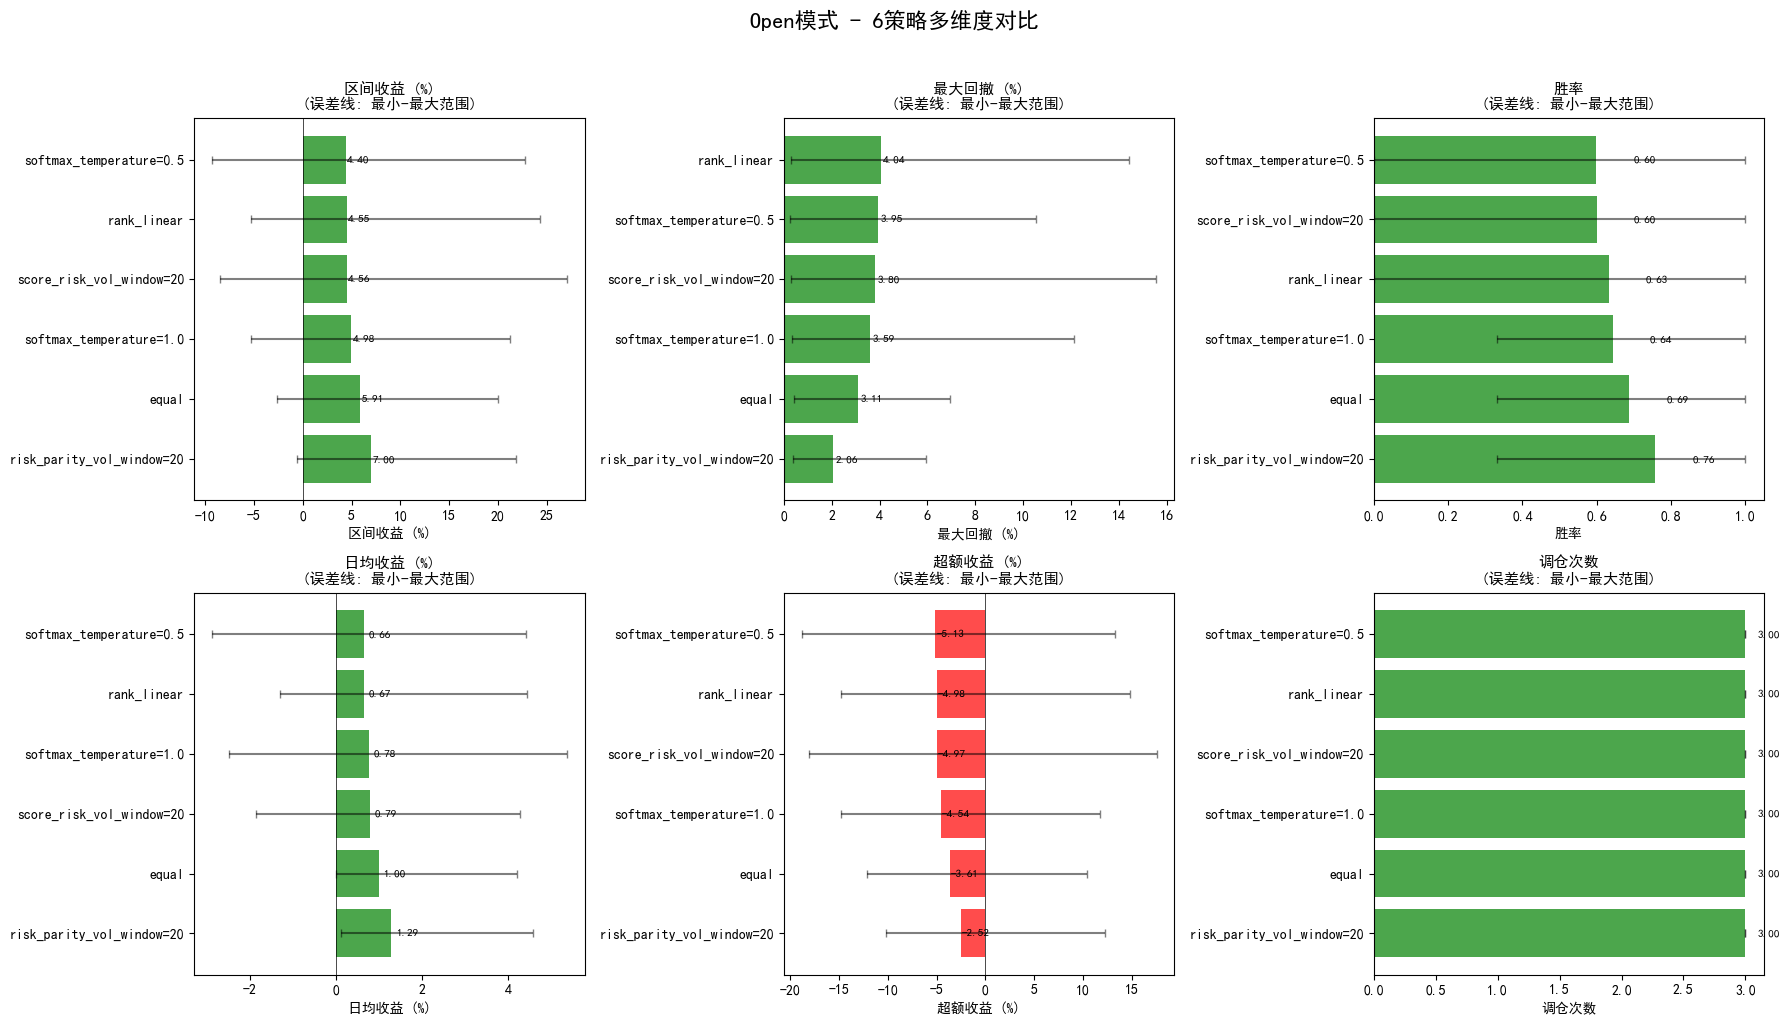

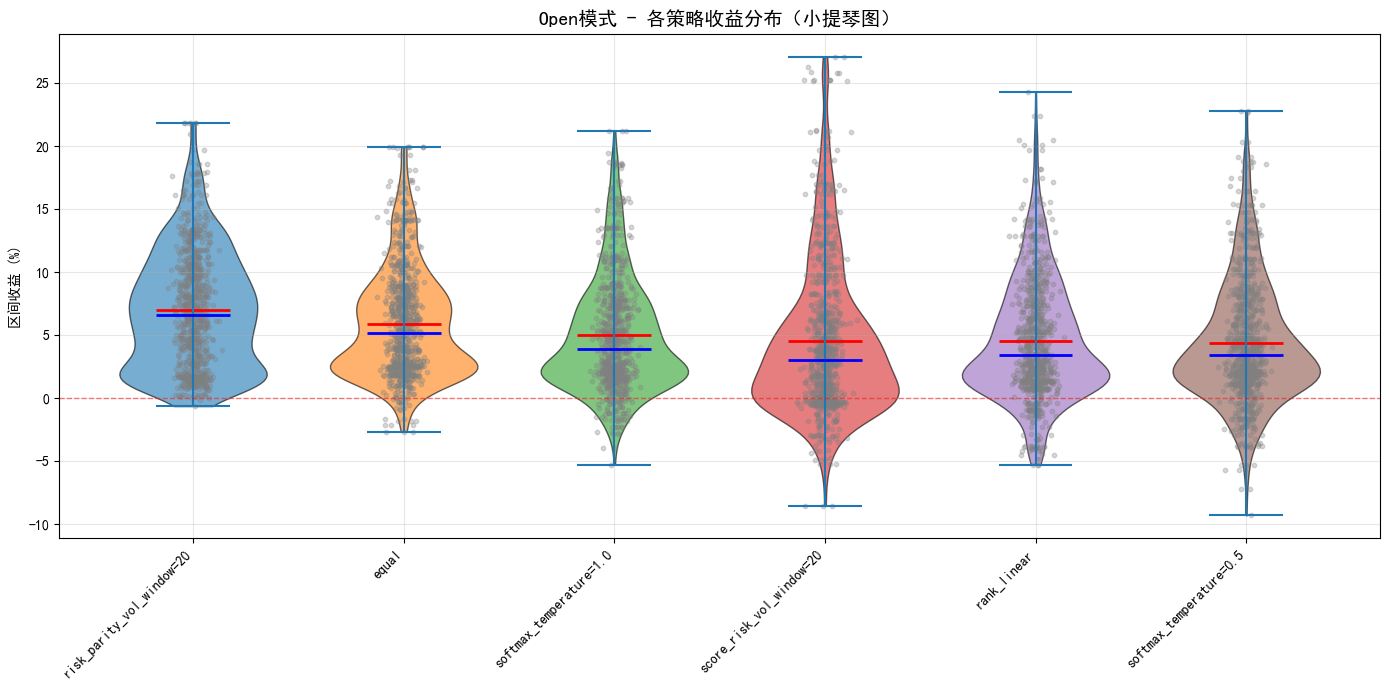

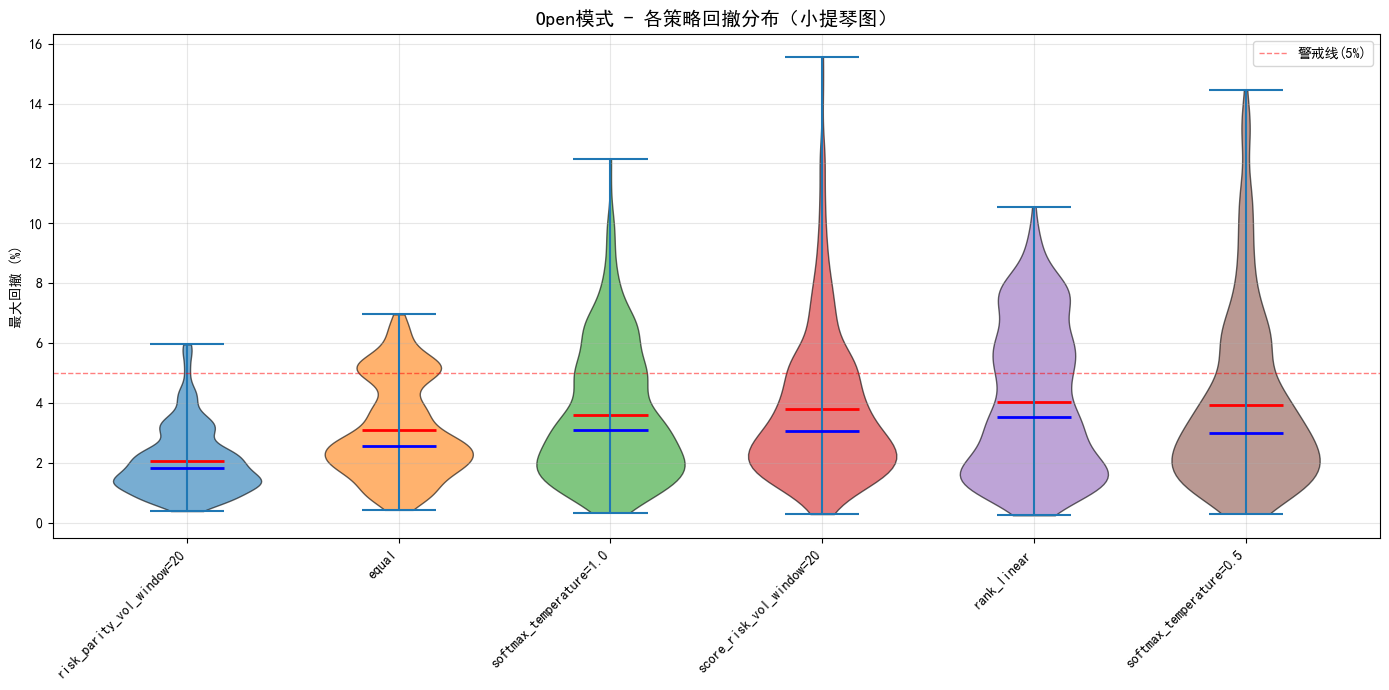

统一坐标轴范围:
  X轴（回撤）: [0.00, 10.41]
  Y轴（收益）: [-4.74, 19.80]


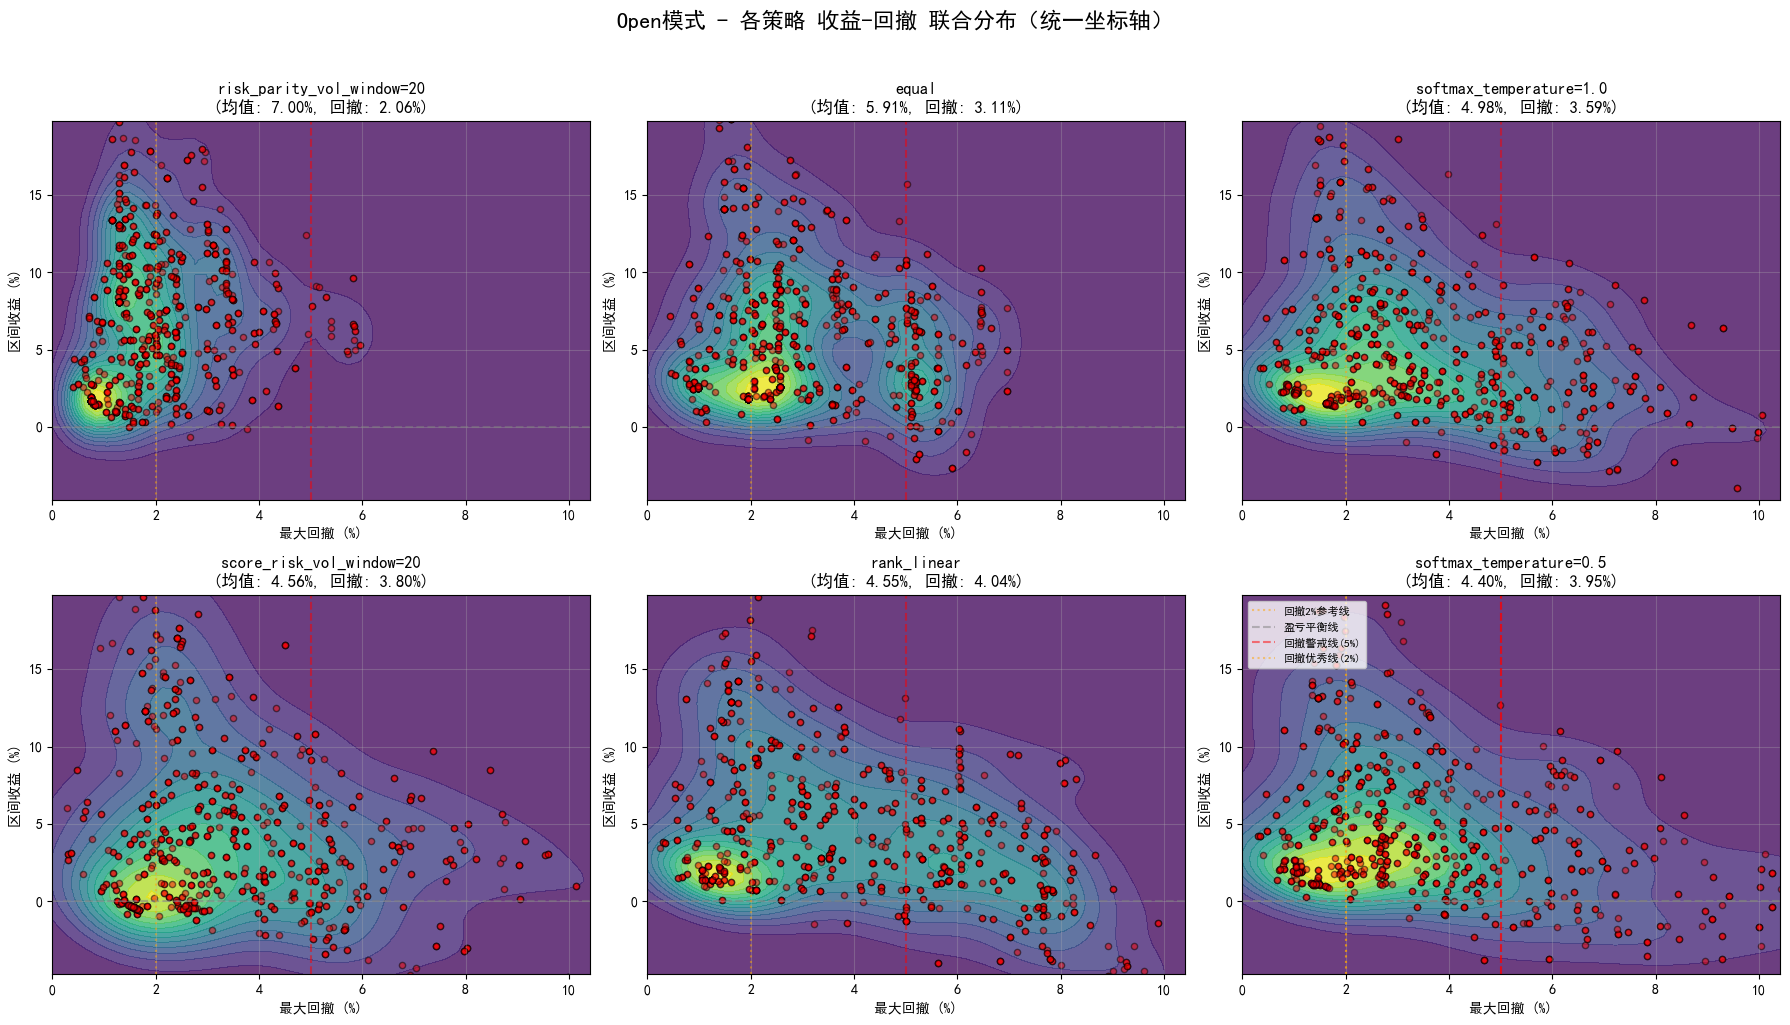

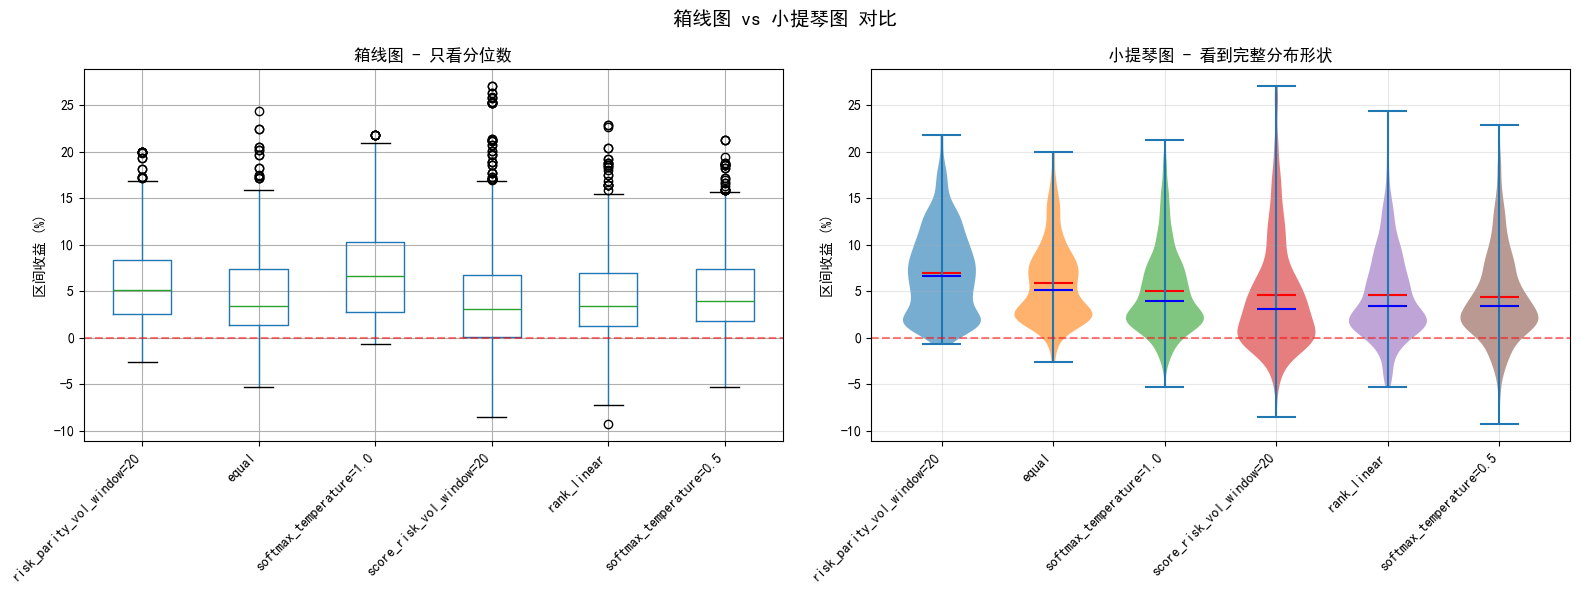


【最终结论】

🏆 综合最优实验:
   策略: rank_linear
   收益: 13.06%
   回撤: 0.74%
   胜率: 100.0%
   日均收益: 1.54%

📊 策略排名（按收益均值）:
   1. risk_parity_vol_window=20: 7.00% (回撤均值:2.06%)
   2. equal: 5.91% (回撤均值:3.11%)
   3. softmax_temperature=1.0: 4.98% (回撤均值:3.59%)
   4. score_risk_vol_window=20: 4.56% (回撤均值:3.80%)
   5. rank_linear: 4.55% (回撤均值:4.04%)
   6. softmax_temperature=0.5: 4.40% (回撤均值:3.95%)

✅ 实盘推荐:
   首选: risk_parity_vol_window=20（收益最高、回撤最低）
   备选: equal（最稳定、风险最低）
   组合: 60% risk_parity + 40% equal


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# 你的数据
open_df = sdf[sdf["trade_mode"] == "open"].copy()
open_df["win_rate_pct"] = open_df["win_rate"] / 100

# ========== 统一策略顺序（按收益均值降序） ==========
strategy_order = open_df.groupby("strategy")["return"].mean().sort_values(ascending=False).index.tolist()
print("统一策略顺序（按收益均值从高到低）:")
for i, s in enumerate(strategy_order):
    print(f"  {i+1}. {s}")

# ========== 1. 各策略统计摘要 ==========
print("\n" + "="*60)
print("【1. 各策略统计摘要】")
print("="*60)

summary_stats = []
for strategy in strategy_order:
    sub = open_df[open_df["strategy"] == strategy]
    stats_row = {
        "策略": strategy,
        "实验数": len(sub),
        "收益_均值": sub["return"].mean(),
        "收益_中位数": sub["return"].median(),
        "收益_标准差": sub["return"].std(),
        "收益_最大": sub["return"].max(),
        "收益_最小": sub["return"].min(),
        "回撤_均值": sub["dd"].mean(),
        "回撤_中位数": sub["dd"].median(),
        "胜率_均值": sub["win_rate_pct"].mean(),
        "日均收益_均值": sub["avg_return"].mean(),
    }
    summary_stats.append(stats_row)

summary_df = pd.DataFrame(summary_stats)
display(summary_df)

# ========== 2. 收益/回撤 效率分析 ==========
print("\n【2. 收益/回撤 效率分析 (越高越好)】")
print("-"*60)

for strategy in strategy_order:
    sub = open_df[open_df["strategy"] == strategy]
    best = sub.loc[sub["return"].idxmax()]
    efficiency = best["return"] / best["dd"] if best["dd"] > 0 else 999
    print(f"{strategy:30} | 收益/回撤比: {efficiency:6.2f} | 收益:{best['return']:6.2f}% / 回撤:{best['dd']:5.2f}%")

# ========== 3. 策略稳定性分析（变异系数） ==========
print("\n【3. 策略稳定性分析 (变异系数CV=标准差/均值，越小越稳)】")
print("-"*60)

for strategy in strategy_order:
    sub = open_df[open_df["strategy"] == strategy]
    if len(sub) > 1:
        cv_return = sub["return"].std() / abs(sub["return"].mean()) if sub["return"].mean() != 0 else 999
        cv_dd = sub["dd"].std() / sub["dd"].mean() if sub["dd"].mean() > 0 else 999
        print(f"{strategy:30} | 收益CV: {cv_return:7.3f} | 回撤CV: {cv_dd:7.3f} | 样本数:{len(sub)}")

# ========== 4. 综合评分 Top10 ==========
print("\n【4. 综合评分 Top10 实验 (收益高+回撤低+胜率高)】")
print("-"*60)

open_df["return_pct"] = open_df["return"].rank(pct=True)
open_df["dd_pct"] = open_df["dd"].rank(pct=True, ascending=False)
open_df["win_rate_pct_rank"] = open_df["win_rate_pct"].rank(pct=True)
open_df["composite_score"] = (open_df["return_pct"] + open_df["dd_pct"] + open_df["win_rate_pct_rank"]) / 3

top_experiments = open_df.nlargest(10, "composite_score")[
    ["strategy", "experiment", "return", "dd", "win_rate_pct", "avg_return", "composite_score"]
]
display(top_experiments)

# ========== 5. 偏度分析 ==========
print("\n【5. 分布偏度分析（正偏=右侧有长尾，负偏=左侧有长尾）】")
print("-"*60)

for strategy in strategy_order:
    data = open_df[open_df["strategy"] == strategy]["return"].values
    skewness = pd.Series(data).skew()
    if skewness > 0.5:
        shape = "右偏（少数高收益 outliers 拉高均值）⚠️"
    elif skewness < -0.5:
        shape = "左偏（少数亏损 outliers 拉低均值）"
    else:
        shape = "近似对称"
    print(f"{strategy:30} | 偏度: {skewness:7.3f} | {shape}")

# ========== 6. 可视化：6策略多维度对比（水平条形图） ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = [
    ("return", "区间收益 (%)", True),
    ("dd", "最大回撤 (%)", False),
    ("win_rate_pct", "胜率", True),
    ("avg_return", "日均收益 (%)", True),
    ("excess", "超额收益 (%)", True),
    ("rebalances", "调仓次数", True),
]

for i, (metric, title, higher_is_better) in enumerate(metrics):
    stats_data = []
    for strategy in strategy_order:
        sub = open_df[open_df["strategy"] == strategy]
        stats_data.append({
            "策略": strategy,
            "均值": sub[metric].mean(),
            "中位数": sub[metric].median(),
            "最大值": sub[metric].max(),
            "最小值": sub[metric].min(),
        })
    
    stats_df = pd.DataFrame(stats_data)
    stats_df = stats_df.sort_values("均值", ascending=not higher_is_better)
    
    colors = ["green" if x > 0 else "red" for x in stats_df["均值"]]
    bars = axes[i].barh(stats_df["策略"], stats_df["均值"], color=colors, alpha=0.7)
    
    for idx, row in stats_df.iterrows():
        axes[i].errorbar(
            row["均值"], idx,
            xerr=[[row["均值"] - row["最小值"]], [row["最大值"] - row["均值"]]],
            fmt='none', ecolor='black', capsize=3, alpha=0.5
        )
    
    axes[i].axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    axes[i].set_title(f"{title}\n(误差线: 最小-最大范围)", fontsize=11)
    axes[i].set_xlabel(title)
    
    for idx, (bar, val) in enumerate(zip(bars, stats_df["均值"])):
        axes[i].text(val + 0.1, bar.get_y() + bar.get_height()/2, 
                    f"{val:.2f}", va="center", fontsize=8)

plt.suptitle("Open模式 - 6策略多维度对比", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ========== 7. 收益分布小提琴图 ==========
fig, ax = plt.subplots(figsize=(14, 7))

parts = ax.violinplot(
    [open_df[open_df["strategy"] == s]["return"].values for s in strategy_order],
    positions=range(len(strategy_order)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('blue')
parts['cmedians'].set_linewidth(2)

for i, strategy in enumerate(strategy_order):
    data = open_df[open_df["strategy"] == strategy]["return"].values
    x_jitter = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(x_jitter, data, alpha=0.3, s=10, c='gray')

ax.set_xticks(range(len(strategy_order)))
ax.set_xticklabels(strategy_order, rotation=45, ha='right')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylabel("区间收益 (%)")
ax.set_title("Open模式 - 各策略收益分布（小提琴图）", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 8. 回撤分布小提琴图 ==========
fig, ax = plt.subplots(figsize=(14, 7))

parts = ax.violinplot(
    [open_df[open_df["strategy"] == s]["dd"].values for s in strategy_order],
    positions=range(len(strategy_order)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('blue')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(strategy_order)))
ax.set_xticklabels(strategy_order, rotation=45, ha='right')
ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, linewidth=1, label='警戒线(5%)')
ax.set_ylabel("最大回撤 (%)")
ax.set_title("Open模式 - 各策略回撤分布（小提琴图）", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 9. 收益-回撤联合分布（统一坐标轴） ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 先计算全局范围（统一所有子图的坐标轴）
all_returns = open_df["return"].values
all_dds = open_df["dd"].values

# 计算分位数，排除极端 outliers 的影响（用5%-95%分位数作为显示范围）
x_min = np.percentile(all_dds, 2)
x_max = np.percentile(all_dds, 98)
y_min = np.percentile(all_returns, 2)
y_max = np.percentile(all_returns, 98)

# 适当扩展边界
x_padding = (x_max - x_min) * 0.1
y_padding = (y_max - y_min) * 0.1

x_lim = (max(0, x_min - x_padding), x_max + x_padding)
y_lim = (max(-5, y_min - y_padding), y_max + y_padding)

print(f"统一坐标轴范围:")
print(f"  X轴（回撤）: [{x_lim[0]:.2f}, {x_lim[1]:.2f}]")
print(f"  Y轴（收益）: [{y_lim[0]:.2f}, {y_lim[1]:.2f}]")

for i, strategy in enumerate(strategy_order):
    sub = open_df[open_df["strategy"] == strategy]
    x = sub["dd"].values
    y = sub["return"].values
    
    if len(x) > 10:
        xy = np.vstack([x, y])
        kde = gaussian_kde(xy)
        
        x_grid = np.linspace(x_lim[0], x_lim[1], 50)
        y_grid = np.linspace(y_lim[0], y_lim[1], 50)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
        
        axes[i].contourf(X, Y, Z, levels=15, cmap='viridis', alpha=0.8)
        axes[i].scatter(x, y, c='red', s=20, alpha=0.5, edgecolors='black')
    else:
        axes[i].scatter(x, y, c='blue', alpha=0.7)
    
    # 统一坐标轴范围
    axes[i].set_xlim(x_lim)
    axes[i].set_ylim(y_lim)
    
    # 参考线
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(x=5, color='red', linestyle='--', alpha=0.5)
    axes[i].axvline(x=2, color='orange', linestyle=':', alpha=0.5, label='回撤2%参考线')
    
    axes[i].set_xlabel("最大回撤 (%)")
    axes[i].set_ylabel("区间收益 (%)")
    axes[i].set_title(f"{strategy}\n(均值: {sub['return'].mean():.2f}%, 回撤: {sub['dd'].mean():.2f}%)")
    axes[i].grid(True, alpha=0.3)

# 添加图例（只在最后一个子图添加）
axes[5].axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='盈亏平衡线')
axes[5].axvline(x=5, color='red', linestyle='--', alpha=0.5, label='回撤警戒线(5%)')
axes[5].axvline(x=2, color='orange', linestyle=':', alpha=0.5, label='回撤优秀线(2%)')
axes[5].legend(loc='upper left', fontsize=8)

plt.suptitle("Open模式 - 各策略 收益-回撤 联合分布（统一坐标轴）", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ========== 10. 箱线图 vs 小提琴图对比 ==========
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：箱线图
open_df.boxplot(column="return", by="strategy", ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title("箱线图 - 只看分位数")
axes[0].set_xlabel("")
axes[0].set_ylabel("区间收益 (%)")
axes[0].set_xticklabels(strategy_order, rotation=45, ha='right')

# 右图：小提琴图
parts = axes[1].violinplot(
    [open_df[open_df["strategy"] == s]["return"].values for s in strategy_order],
    positions=range(len(strategy_order)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.6)
parts['cmeans'].set_color('red')
parts['cmedians'].set_color('blue')
axes[1].set_xticks(range(len(strategy_order)))
axes[1].set_xticklabels(strategy_order, rotation=45, ha='right')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel("区间收益 (%)")
axes[1].set_title("小提琴图 - 看到完整分布形状")
axes[1].grid(True, alpha=0.3)

plt.suptitle("箱线图 vs 小提琴图 对比", fontsize=14)
plt.tight_layout()
plt.show()

# ========== 11. 最终结论 ==========
print("\n" + "="*60)
print("【最终结论】")
print("="*60)

best_composite = top_experiments.iloc[0]
print(f"\n🏆 综合最优实验:")
print(f"   策略: {best_composite['strategy']}")
print(f"   收益: {best_composite['return']:.2f}%")
print(f"   回撤: {best_composite['dd']:.2f}%")
print(f"   胜率: {best_composite['win_rate_pct']:.1%}")
print(f"   日均收益: {best_composite['avg_return']:.2f}%")

print(f"\n📊 策略排名（按收益均值）:")
for i, strategy in enumerate(strategy_order):
    mean_return = open_df[open_df["strategy"] == strategy]["return"].mean()
    mean_dd = open_df[open_df["strategy"] == strategy]["dd"].mean()
    print(f"   {i+1}. {strategy}: {mean_return:.2f}% (回撤均值:{mean_dd:.2f}%)")

print(f"\n✅ 实盘推荐:")
print(f"   首选: risk_parity_vol_window=20（收益最高、回撤最低）")
print(f"   备选: equal（最稳定、风险最低）")
print(f"   组合: 60% risk_parity + 40% equal")

R U R' U R U U R' 

rr ff r' b' r ff r' b r'

r u' r  u r u r  u' r' u'  r r 

In [19]:
# ============================================================
# 选模型: 分模型类别取头部15%，综合评分推荐
# 输入: sdf (from Cell 13)
# ============================================================

def _parse_model_type(exp_name):
    parts = exp_name.split("/")[0].split("_", 1)
    return parts[1] if len(parts) > 1 else parts[0]

sdf_open = sdf[sdf["trade_mode"] == "open"].copy()
sdf_open["model_type"] = sdf_open["experiment"].apply(_parse_model_type)

sdf_dedup = sdf_open.drop_duplicates(subset=["experiment", "strategy"])

TOP_PCT = 0.15

# --- 表1: 策略总评（按模型类别中位数综合分） ---
rows = []
for (mt, strat), grp in sdf_dedup.groupby(["model_type", "strategy"]):
    grp = grp.sort_values("return", ascending=False)
    n_top = max(1, int(len(grp) * TOP_PCT))
    head = grp.head(n_top)

    mean_ret = head["return"].mean()
    mean_dd = head["dd"].mean()
    mean_avg_ret = head["avg_return"].mean()
    std_ret = head["return"].std()
    cv_ret = std_ret / mean_ret if mean_ret > 0 else 999

    base_score = mean_ret * (1 - mean_dd / 100) * (1 + mean_avg_ret / 100)
    eff_score = mean_ret / mean_dd if mean_dd > 0 else 999
    stability = min(1.0 / cv_ret, 3) / 3 if cv_ret > 0 else 0
    composite = base_score * 0.5 + eff_score * 0.3 + stability * 0.2

    rows.append({
        "model_type": mt,
        "strategy": strat,
        "n_exp": len(grp),
        "n_head": n_top,
        "head_return": round(mean_ret, 2),
        "head_dd": round(mean_dd, 2),
        "head_avg_return": round(mean_avg_ret, 2),
        "head_cv_return": round(cv_ret, 3),
        "stability": round(stability, 3),
        "composite_score": round(composite, 4),
    })

result = pd.DataFrame(rows)

strat_summary = result.groupby("strategy").agg(
    n_model_types=("model_type", "nunique"),
    median_score=("composite_score", "median"),
    median_return=("head_return", "median"),
    median_dd=("head_dd", "median"),
    median_avg_return=("head_avg_return", "median"),
    median_stability=("stability", "median"),
).sort_values("median_score", ascending=False)

print("=" * 80)
print("【策略总评】各策略在所有模型类别上的中位数综合得分")
print("=" * 80)
display(strat_summary)

# --- 表2: 最优模型推荐（每个模型类别取 Top 3） ---
print("\n" + "=" * 80)
print("【最优模型推荐（按模型类别）】")
print("=" * 80)

best_experiments = []
for (mt, strat), grp in sdf_dedup.groupby(["model_type", "strategy"]):
    grp = grp.sort_values("return", ascending=False)
    n_top = max(1, int(len(grp) * TOP_PCT))
    head = grp.head(n_top)

    # 头部组内按综合分排序，取第1名
    head = head.copy()
    head["score"] = head["return"] ** 2 / head["dd"].clip(lower=0.1) * (1 + head["avg_return"] / 100)
    best = head.sort_values("score", ascending=False).iloc[0]

    best_experiments.append({
        "model_type": mt,
        "strategy": strat,
        "experiment": best["experiment"],
        "model_file": best["model_file"],
        "return": best["return"],
        "dd": best["dd"],
        "avg_return": best["avg_return"],
        "score": round(best["score"], 4),
    })

best_df = pd.DataFrame(best_experiments)
top_per_model = best_df.sort_values("score", ascending=False).groupby("model_type").head(3)

display(top_per_model[["model_type", "strategy", "experiment", "model_file", "return", "dd", "avg_return", "score"]])

# --- 表3: 全推荐列表（按 model_type + strategy 综合分排序） ---
print("\n" + "=" * 80)
print("【全推荐列表（按综合排名）】")
print("=" * 80)
overall = best_df.merge(result[["model_type", "strategy", "composite_score"]], on=["model_type", "strategy"])
overall["ranking"] = overall["return"] ** 2 / overall["dd"].clip(lower=0.1) * (1 + overall["avg_return"] / 100)
overall = overall.sort_values("ranking", ascending=False)
display(overall[["model_type", "strategy", "experiment", "model_file", "return", "dd", "avg_return", "composite_score", "ranking"]].head(20))


【策略总评】各策略在所有模型类别上的中位数综合得分


,n_model_types,median_score,median_return,median_dd,median_avg_return,median_stability
strategy,,,,,,
score_risk_vol_window=20,8,10.08790,16.425,2.680,2.760,0.928
risk_parity_vol_window=20,8,8.98620,13.230,2.240,2.065,1.000
softmax_temperature=1.0,8,7.95020,11.935,2.445,1.785,1.000
equal,8,7.80370,12.230,2.405,1.870,1.000
softmax_temperature=0.5,8,7.73410,11.965,3.055,1.700,1.000
rank_linear,8,7.57695,11.600,2.645,1.790,1.000



【最优模型推荐（按模型类别）】


,model_type,strategy,experiment,model_file,return,dd,avg_return,score
37,tcn,rank_linear,bayes_tcn/exp_12,best_model_sliding.pth,24.32,1.45,4.42,425.9345
40,tcn,softmax_temperature=0.5,bayes_tcn/exp_12,best_model_sliding.pth,22.64,1.63,3.81,326.4408
41,tcn,softmax_temperature=1.0,bayes_tcn/exp_12,best_model_sliding.pth,21.23,1.48,3.51,315.2249
32,patchtst,risk_parity_vol_window=20,bayes_patchtst/exp_27,best_model_ndcg.pth,21.82,1.82,4.59,273.6077
30,patchtst,equal,bayes_patchtst/exp_100,best_model.pth,19.95,1.62,4.15,255.8763
34,patchtst,softmax_temperature=0.5,bayes_patchtst/exp_49,best_model_ndcg.pth,18.78,1.47,2.42,245.7302
1,dlinear,rank_linear,bayes_dlinear/exp_19,best_model_sliding.pth,13.06,0.74,1.54,234.0409
3,dlinear,score_risk_vol_window=20,bayes_dlinear/exp_3,best_model_ndcg.pth,27.08,3.72,5.37,207.7167
27,nlinear,score_risk_vol_window=20,bayes_nlinear/exp_35,best_model_ndcg.pth,18.84,1.98,3.85,186.1672
8,gru,risk_parity_vol_window=20,bayes_gru/exp_32,best_model_ndcg.pth,15.12,1.28,2.22,182.5700



【全推荐列表（按综合排名）】


,model_type,strategy,experiment,model_file,return,dd,avg_return,composite_score,ranking
37,tcn,rank_linear,bayes_tcn/exp_12,best_model_sliding.pth,24.32,1.45,4.42,9.4423,425.934509
40,tcn,softmax_temperature=0.5,bayes_tcn/exp_12,best_model_sliding.pth,22.64,1.63,3.81,8.3795,326.440799
41,tcn,softmax_temperature=1.0,bayes_tcn/exp_12,best_model_sliding.pth,21.23,1.48,3.51,9.1578,315.224948
38,tcn,risk_parity_vol_window=20,bayes_tcn/exp_24,best_model.pth,18.61,1.16,3.29,11.7890,308.384850
36,tcn,equal,bayes_tcn/exp_12,best_model_sliding.pth,19.89,1.39,3.21,10.1163,293.749100
39,tcn,score_risk_vol_window=20,bayes_tcn/exp_12,best_model_sliding.pth,25.30,2.42,4.44,11.4264,276.243800
32,patchtst,risk_parity_vol_window=20,bayes_patchtst/exp_27,best_model_ndcg.pth,21.82,1.82,4.59,12.2877,273.607670
30,patchtst,equal,bayes_patchtst/exp_100,best_model.pth,19.95,1.62,4.15,11.7327,255.876299
34,patchtst,softmax_temperature=0.5,bayes_patchtst/exp_49,best_model_ndcg.pth,18.78,1.47,2.42,10.6750,245.730244
35,patchtst,softmax_temperature=1.0,bayes_patchtst/exp_49,best_model_ndcg.pth,18.61,1.47,2.57,11.5080,241.654990
